<a href="https://colab.research.google.com/github/jgocana/Trabalhos-TP-547/blob/master/Trabalho%20Final%20Parte%202/figura3_qpsk_rayleigh.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
!pip install numpy
!pip install matplotlib

Eb/N0 =  0 dB | BER DI = 1.46231e-01 | BER DII = 1.46231e-01
Eb/N0 =  2 dB | BER DI = 1.08641e-01 | BER DII = 1.08641e-01
Eb/N0 =  4 dB | BER DI = 7.69945e-02 | BER DII = 7.69945e-02
Eb/N0 =  6 dB | BER DI = 5.29230e-02 | BER DII = 5.29230e-02
Eb/N0 =  8 dB | BER DI = 3.55270e-02 | BER DII = 3.55270e-02
Eb/N0 = 10 dB | BER DI = 2.32825e-02 | BER DII = 2.32825e-02
Eb/N0 = 12 dB | BER DI = 1.52020e-02 | BER DII = 1.52020e-02
Eb/N0 = 14 dB | BER DI = 9.79700e-03 | BER DII = 9.79700e-03
Eb/N0 = 16 dB | BER DI = 6.10300e-03 | BER DII = 6.10300e-03
Eb/N0 = 18 dB | BER DI = 3.90500e-03 | BER DII = 3.90500e-03
Eb/N0 = 20 dB | BER DI = 2.44300e-03 | BER DII = 2.44300e-03
Eb/N0 = 22 dB | BER DI = 1.58050e-03 | BER DII = 1.58050e-03
Eb/N0 = 24 dB | BER DI = 1.00900e-03 | BER DII = 1.00900e-03
Eb/N0 = 26 dB | BER DI = 6.25500e-04 | BER DII = 6.25500e-04
Eb/N0 = 28 dB | BER DI = 3.88000e-04 | BER DII = 3.88000e-04
Eb/N0 = 30 dB | BER DI = 2.66500e-04 | BER DII = 2.66500e-04


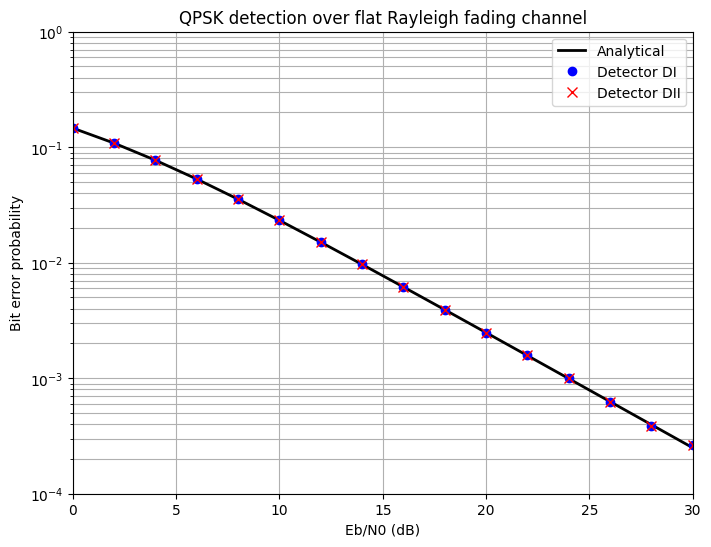

In [1]:
# Recriação da Figura 3 do artigo:
# "QPSK Detection Schemes for Rayleigh Fading Channels"
# Objetivo: simular a BER de dois detectores QPSK em canal Rayleigh plano
# e comparar os resultados simulados com a expressão analítica apresentada no artigo.

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Parâmetros da simulação
# ============================================================

np.random.seed(1)                 # Semente para garantir reprodutibilidade

EbN0_dB = np.arange(0, 31, 2)      # Faixa de Eb/N0 em dB, como na figura do artigo
EbN0_linear = 10**(EbN0_dB / 10)   # Conversão de dB para escala linear

N_bits = 2_000_000                # Número de bits simulados para cada valor de Eb/N0

# Neste código, utiliza-se uma constelação QPSK com níveis I/Q iguais a +/-1.
# Assim:
#   Es = energia por símbolo = |1+j|^2 = 2
#   QPSK transmite 2 bits por símbolo
#   Eb = Es / 2 = 1
Eb = 1.0

# Constelação QPSK com mapeamento Gray:
# 00 ->  1 + 1j
# 01 -> -1 + 1j
# 11 -> -1 - 1j
# 10 ->  1 - 1j
constellation = np.array([
    1 + 1j,
   -1 + 1j,
   -1 - 1j,
    1 - 1j
])

bits_constellation = np.array([
    [0, 0],
    [0, 1],
    [1, 1],
    [1, 0]
])

# Vetores para armazenar a BER simulada de cada detector
ber_DI = np.zeros(len(EbN0_dB))
ber_DII = np.zeros(len(EbN0_dB))

# ============================================================
# 2. Geração dos bits e dos símbolos QPSK transmitidos
# ============================================================

# Garante-se que o número de bits seja par, pois QPSK transmite 2 bits por símbolo.
if N_bits % 2 != 0:
    N_bits += 1

bits_tx = np.random.randint(0, 2, N_bits)
bit_pairs = bits_tx.reshape(-1, 2)

# Conversão dos pares de bits para índices da constelação Gray:
# 00 -> 0
# 01 -> 1
# 11 -> 2
# 10 -> 3
symbol_indices = np.zeros(bit_pairs.shape[0], dtype=int)

symbol_indices[(bit_pairs[:, 0] == 0) & (bit_pairs[:, 1] == 0)] = 0
symbol_indices[(bit_pairs[:, 0] == 0) & (bit_pairs[:, 1] == 1)] = 1
symbol_indices[(bit_pairs[:, 0] == 1) & (bit_pairs[:, 1] == 1)] = 2
symbol_indices[(bit_pairs[:, 0] == 1) & (bit_pairs[:, 1] == 0)] = 3

symbols_tx = constellation[symbol_indices]
N_symbols = len(symbols_tx)

# ============================================================
# 3. Simulação de Monte Carlo para cada valor de Eb/N0
# ============================================================

for idx, gamma_b in enumerate(EbN0_linear):

    # ------------------------------------------------------------
    # 3.1 Cálculo do ruído AWGN complexo
    # ------------------------------------------------------------
    # gamma_b = Eb/N0  ->  N0 = Eb/gamma_b
    # O ruído complexo possui variância N0/2 na parte real
    # e N0/2 na parte imaginária.
    N0 = Eb / gamma_b
    noise_sigma = np.sqrt(N0 / 2)

    noise = noise_sigma * (
        np.random.randn(N_symbols) + 1j * np.random.randn(N_symbols)
    )

    # ------------------------------------------------------------
    # 3.2 Canal Rayleigh plano
    # ------------------------------------------------------------
    # O artigo considera uma amplitude Rayleigh alpha com potência normalizada:
    # E[alpha^2] = 1.
    # Se U é uma variável uniforme em (0,1), então:
    # alpha = sqrt(-ln(U))
    # possui pdf f(alpha) = 2 alpha exp(-alpha^2), alpha >= 0.
    U = np.random.rand(N_symbols)
    alpha = np.sqrt(-np.log(U))

    # Após a compensação ideal de fase, o modelo equivalente é:
    # z = alpha*s + n
    # onde:
    #   s é o símbolo QPSK transmitido;
    #   alpha é a amplitude do canal Rayleigh;
    #   n é o ruído AWGN complexo.
    z = alpha * symbols_tx + noise

    # ------------------------------------------------------------
    # 3.3 Detector I
    # ------------------------------------------------------------
    # Detector I:
    # Compara z com alpha*s_i para todos os símbolos QPSK possíveis
    # e escolhe o símbolo que minimiza |z - alpha*s_i|.
    # Ou seja, a constelação de referência é escalada pela amplitude do canal.
    distances_DI = np.abs(z[:, None] - alpha[:, None] * constellation[None, :])
    detected_indices_DI = np.argmin(distances_DI, axis=1)

    bits_rx_DI = bits_constellation[detected_indices_DI].reshape(-1)
    ber_DI[idx] = np.mean(bits_rx_DI != bits_tx)

    # ------------------------------------------------------------
    # 3.4 Detector II
    # ------------------------------------------------------------
    # Detector II:
    # Primeiro normaliza a amostra recebida dividindo por alpha:
    # z_norm = z / alpha.
    # Depois compara z_norm com os símbolos originais da constelação QPSK.
    # Ou seja, a amostra recebida é normalizada antes da decisão.
    z_norm = z / alpha

    distances_DII = np.abs(z_norm[:, None] - constellation[None, :])
    detected_indices_DII = np.argmin(distances_DII, axis=1)

    bits_rx_DII = bits_constellation[detected_indices_DII].reshape(-1)
    ber_DII[idx] = np.mean(bits_rx_DII != bits_tx)

    print(
        f"Eb/N0 = {EbN0_dB[idx]:2d} dB | "
        f"BER DI = {ber_DI[idx]:.5e} | "
        f"BER DII = {ber_DII[idx]:.5e}"
    )

# ============================================================
# 4. Curva analítica do artigo
# ============================================================

# Expressão analítica da probabilidade de erro de bit para QPSK
# em canal Rayleigh plano, apresentada no artigo:
#
# Pb = 1/2 * (1 - sqrt((Eb/N0) / (1 + Eb/N0)))
#
# Essa expressão corresponde ao resultado final obtido para os dois detectores.
ber_analytical = 0.5 * (1 - np.sqrt(EbN0_linear / (1 + EbN0_linear)))

# ============================================================
# 5. Gráfico final: recriação da Figura 3
# ============================================================

plt.figure(figsize=(8, 6))

plt.semilogy(EbN0_dB, ber_analytical, "k-", linewidth=2, label="Analytical")
plt.semilogy(EbN0_dB, ber_DI, "bo", markersize=6, label="Detector DI")
plt.semilogy(EbN0_dB, ber_DII, "rx", markersize=7, label="Detector DII")

plt.grid(True, which="both")
plt.xlabel("Eb/N0 (dB)")
plt.ylabel("Bit error probability")
plt.title("QPSK detection over flat Rayleigh fading channel")
plt.legend()
plt.ylim(1e-4, 1)
plt.xlim(0, 30)

plt.show()
